# Generator cutoff workflow


In [54]:
# Imports and helpers
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from aislens.config import config
from aislens.generator import eof_decomposition, generate_data

sns.set(style='whitegrid')



In [32]:
# Parameters - edit these for quick tests
COARSEN_FACTOR = 4  # integer factor to coarsen each spatial dim (set 1 to skip)
N_REALIZATIONS_SMALL = 2
MIN_PERIOD_YEARS = 10  # e.g., 2.0 to remove periods shorter than 2 years
MAX_PERIOD_YEARS = None  # e.g., 20.0 to remove periods longer than 20 years
INCLUDE_SEASONALITY = True
OUTPUT_DIR = Path(config.DIR_PROCESSED / 'generator-test')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
def safe_std(x, eps=1e-10):
    return x.where(x > 0, eps)


def coarsen_dataset(ds_var, factor):
    # factor: int or dict mapping dim->factor
    if factor is None or factor == 1:
        return ds_var
    if isinstance(factor, int):
        # apply same factor to all non-time dims
        time_dim = getattr(config, 'TIME_DIM', 'Time')
        spatial_dims = [d for d in ds_var.dims if d != time_dim]
        coarsen_kwargs = {d: factor for d in spatial_dims}
    elif isinstance(factor, dict):
        coarsen_kwargs = factor
    else:
        raise ValueError('COARSEN_FACTOR must be int or dict')
    return ds_var.coarsen(coarsen_kwargs, boundary='trim').mean()


def save_dataset(ds, fname):
    out = Path(fname)
    out.parent.mkdir(parents=True, exist_ok=True)
    ds.to_netcdf(out)
    return out


In [6]:
# Load variability dataset (sorrm_variability.nc)
# try a few config names defensively
var_path = getattr(config, 'FILE_SORRM_VARIABILITY', None)
if var_path is None:
    var_path = getattr(config, 'FILE_VARIABILITY_EXTRAPL', None)
if var_path is None:
    var_path = getattr(config, 'FILE_VARIABILITY', None)
if var_path is None:
    raise RuntimeError('Could not find a variability file path in config (tried FILE_SORRM_VARIABILITY, FILE_VARIABILITY_EXTRAPL, FILE_VARIABILITY)')

print('Using variability file:', var_path)

time_dim = getattr(config, 'TIME_DIM', 'Time')
print('Assumed time dim:', time_dim)

ds = xr.open_dataset(var_path, chunks={time_dim: 36})
var_name = getattr(config, 'SORRM_FLUX_VAR', None)
if var_name is None:
    # fallback: pick first data variable
    var_name = list(ds.data_vars)[0]

print('Variable chosen:', var_name)

# select the DataArray we will use
data = ds[var_name]


Using variability file: /Users/smurugan9/research/aislens/AISLENS/data/processed/sorrm_variability_extrapolated_fillNA_meanAdjusted.nc
Assumed time dim: Time
Variable chosen: timeMonthly_avg_landIceFreshwaterFlux


In [7]:
# Inspect dataset and rename Time -> time if needed
print('Dataset dims:', ds.dims)
print('Coords:', list(ds.coords.keys()))
print('Time range:', ds[time_dim].isel({time_dim:0}).values, 'to', ds[time_dim].isel({time_dim:-1}).values)

if time_dim == 'Time':
    ds = ds.rename({'Time': 'time'})
    data = ds[var_name]
    time_dim = 'time'
    print('Renamed Time -> time')

# quick NaN check
n_nans = int(data.isnull().sum().values)
print('Total NaNs in data:', n_nans)


Dataset dims: Frozen({'y': 601, 'x': 601, 'Time': 3600})
Coords: ['y', 'x', 'spatial_ref', 'Time', 'month']
Time range: 0451-01-16 12:00:00.000001 to 0750-12-16 12:00:00.000001
Renamed Time -> time
Total NaNs in data: 0
Total NaNs in data: 0


In [8]:
# Apply coarsen option (spatial downsampling)
orig_data = data
if COARSEN_FACTOR and COARSEN_FACTOR > 1:
    print('Applying coarsen factor =', COARSEN_FACTOR)
    data = coarsen_dataset(data, COARSEN_FACTOR)
    print('New shape after coarsen:', data.shape)
else:
    print('Skipping coarsen (factor=1)')


Applying coarsen factor = 4
New shape after coarsen: (900, 150, 150)


Sample index chosen (spatial): (0, 0)


TypeError: float() argument must be a string or a real number, not 'cftime._cftime.DatetimeNoLeap'

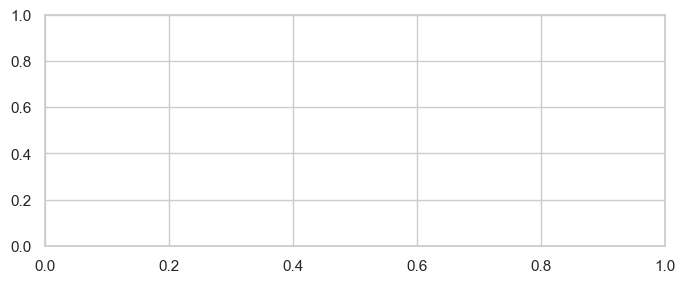

In [10]:
# Quick exploratory diagnostics and small plots
# pick a sample valid grid point (first non-NaN)
import random
import cftime

# find a sample index
valid_mask = ~np.isnan(data.isel({time_dim:0})).values
if valid_mask.ndim == 0:
    sample_idx = None
else:
    # flatten and find first valid
    flat = valid_mask.flatten()
    good = np.where(flat)[0]
    if len(good) == 0:
        sample_idx = None
    else:
        idx_flat = good[0]
        # map back to multi-index
        shape = data.isel({time_dim:0}).shape
        multi_idx = np.unravel_index(idx_flat, shape)
        sample_idx = multi_idx

print('Sample index chosen (spatial):', sample_idx)

# timeseries at sample cell
if sample_idx is not None:
    sel = {d: sample_idx[i] for i,d in enumerate([d for d in data.isel({time_dim:0}).dims])}
    ts = data.isel({**{time_dim: slice(None)}, **sel})
    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(ts[time_dim].values, ts.values)
    ax.set_title('Sample gridpoint timeseries')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_timeseries.png')
    plt.show()

# spatial mean map
mean_map = data.mean(dim=time_dim)
if getattr(mean_map, 'ndim', 2) and mean_map.ndim >= 2:
    fig, ax = plt.subplots(figsize=(6,4))
    im = ax.imshow(mean_map.values, origin='lower')
    ax.set_title('Spatial mean (time-averaged)')
    plt.colorbar(im, ax=ax)
    plt.savefig(OUTPUT_DIR / 'mean_map.png')
    plt.show()

# histogram
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(data.values.flatten(), bins=60)
ax.set_title('Histogram of data values')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'histogram.png')
plt.show()


In [12]:
# Normalize variability for EOF
print('Computing normalization...')
data_tmean = data.mean(dim=time_dim)
data_tstd = data.std(dim=time_dim).where(lambda x: x>0, 1e-10)
data_norm = (data - data_tmean) / data_tstd

print('data_norm mean (should be ~0):', float(data_norm.mean().compute()))
print('data_norm std (should be ~1):', float(data_norm.std().compute()))


Computing normalization...
data_norm mean (should be ~0): 0.5406643337102854
data_norm mean (should be ~0): 0.5406643337102854
data_norm std (should be ~1): 0.8194232528672744
data_norm std (should be ~1): 0.8194232528672744


Running EOF decomposition (may take a moment)...
EOF results: eofs: (150, 150, 900) pcs: (900, 900) nmodes: 900
Explained variance (first 5): <xarray.DataArray 'explained_variance_ratio' (mode: 5)>
array([0.16641051, 0.09659205, 0.08292472, 0.06494363, 0.04767488])
Coordinates:
  * mode     (mode) int64 1 2 3 4 5
EOF results: eofs: (150, 150, 900) pcs: (900, 900) nmodes: 900
Explained variance (first 5): <xarray.DataArray 'explained_variance_ratio' (mode: 5)>
array([0.16641051, 0.09659205, 0.08292472, 0.06494363, 0.04767488])
Coordinates:
  * mode     (mode) int64 1 2 3 4 5


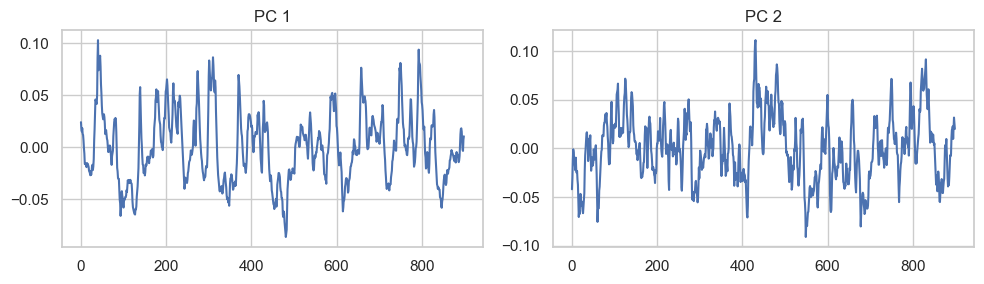

In [ ]:
# EOF decomposition
print('Running EOF decomposition')
model, eofs, pcs, nmodes, varexpl = eof_decomposition(data_norm)
print('EOF results: eofs:', getattr(eofs, 'shape', None), 'pcs:', getattr(pcs, 'shape', None), 'nmodes:', nmodes)
print('Explained variance (first 5):', varexpl[:5])

# convert pcs to DataArray if needed for plotting
pcs_da = pcs if hasattr(pcs, 'dims') else xr.DataArray(pcs, dims=(data_norm[time_dim].dims[0], 'mode'))
#pcs_da = xr.DataArray(pcs)

# plot first two PCs
fig, axes = plt.subplots(1,2, figsize=(10,3))
for k in range(min(2, pcs_da.shape[1])):
    axes[k].plot(pcs_da[:, k])
    axes[k].set_title(f'PC {k+1}')
plt.tight_layout()
plt.show()


In [ ]:
# Minimal phase_randomization with optional spectral cutoff
import numpy as np

def phase_randomization_minimal(pcs, n_realizations, min_period_years=None, max_period_years=None,
                                sampling_months=1.0, retain_outside=False, rescale_variance=True,
                                random_state=None, tiny_eps=1e-12):
    """
    Minimal phase randomization with optional spectral passband + optional rescaling.

    - pcs: ndarray (ntime, nmodes)
    - n_realizations: int
    - min_period_years/max_period_years: bounds on periods to keep (in years)
    - sampling_months: sampling interval (months) — default 1.0 for monthly data
    - retain_outside: if True, keep original spectral coeffs outside the passband; if False zero them
    - rescale_variance: if True, rescale each generated PC realization to match the original
                        band-limited variance for that mode
    - tiny_eps: numerical floor for variance comparisons
    """
    rng = np.random.default_rng(random_state)
    t_length, nmodes = pcs.shape
    new_pcs = np.empty((n_realizations, t_length, nmodes), dtype=float)

    # FFT frequency axis (cycles per month if sampling_months=1.0)
    freqs = np.fft.rfftfreq(t_length, d=sampling_months)
    with np.errstate(divide='ignore', invalid='ignore'):
        periods_months = np.where(freqs > 0, 1.0 / freqs, np.inf)
    periods_years = periods_months / 12.0

    # frequency mask (True => inside passband)
    mask = np.ones_like(freqs, dtype=bool)
    if min_period_years is not None:
        mask &= (periods_years >= min_period_years)
    if max_period_years is not None:
        mask &= (periods_years <= max_period_years)

    for m in range(nmodes):
        fl = pcs[:, m]
        spec = np.fft.rfft(fl)
        amp = np.abs(spec)

        # build original band-limited series to compute target band variance
        orig_band_spec = spec.copy()
        orig_band_spec[~mask] = 0.0
        orig_band_series = np.fft.irfft(orig_band_spec, n=t_length)
        orig_band_var = float(np.var(orig_band_series))

        # preserve DC (mean)
        dc = spec[0]

        for i in range(n_realizations):
            phases = np.exp(1.0j * rng.uniform(0, 2 * np.pi, size=spec.shape))
            new_spec = np.zeros_like(spec, dtype=complex)
            # inside passband: use original amplitude with randomized phase
            new_spec[mask] = amp[mask] * phases[mask]
            # outside: either keep original or zero
            if retain_outside:
                new_spec[~mask] = spec[~mask]
            # keep DC
            new_spec[0] = dc

            # inverse transform
            recon = np.fft.irfft(new_spec, n=t_length).real

            if rescale_variance:
                new_var = float(np.var(recon))
                # scale to match original band variance (if both non-zero)
                if new_var > tiny_eps and orig_band_var > tiny_eps:
                    scale = (orig_band_var / new_var) ** 0.5
                    recon = recon * scale
                # if original band var is ~0, leave recon as-is (no energy to match)

            new_pcs[i, :, m] = recon

    return new_pcs


In [70]:
MIN_PERIOD_YEARS = None # 0.33
MAX_PERIOD_YEARS = None

# Generate randomized PCs and reconstruct a small number of realizations
print('Generating randomized PCs...')
pcs_arr = pcs if hasattr(pcs, 'shape') else np.asarray(pcs)
new_pcs = phase_randomization_minimal(pcs_arr, N_REALIZATIONS_SMALL,
                                      min_period_years=MIN_PERIOD_YEARS,
                                      max_period_years=MAX_PERIOD_YEARS,
                                      sampling_months=1.0, retain_outside=False)
print('new_pcs shape:', new_pcs.shape)

# reconstruct first realization
recon = generate_data(model, new_pcs, 0, nmodes, 1)
# recon is normalized; convert to physical units
recon_phys = (recon * data_tstd) + data_tmean
# wrap into DataArray if not already
if not hasattr(recon_phys, 'dims'):
    recon_da = xr.DataArray(recon_phys, dims=data.dims, coords=data.coords)
else:
    recon_da = recon_phys

print('Reconstructed realization shape:', recon_da.shape)


Generating randomized PCs...
new_pcs shape: (2, 900, 900)
new_pcs shape: (2, 900, 900)
Reconstructed realization shape: (900, 150, 150)
Reconstructed realization shape: (900, 150, 150)


In [71]:
recon_phys_ts = recon_phys.mean(["x","y"]).compute()
data_ts = data.mean(["x","y"]).compute()

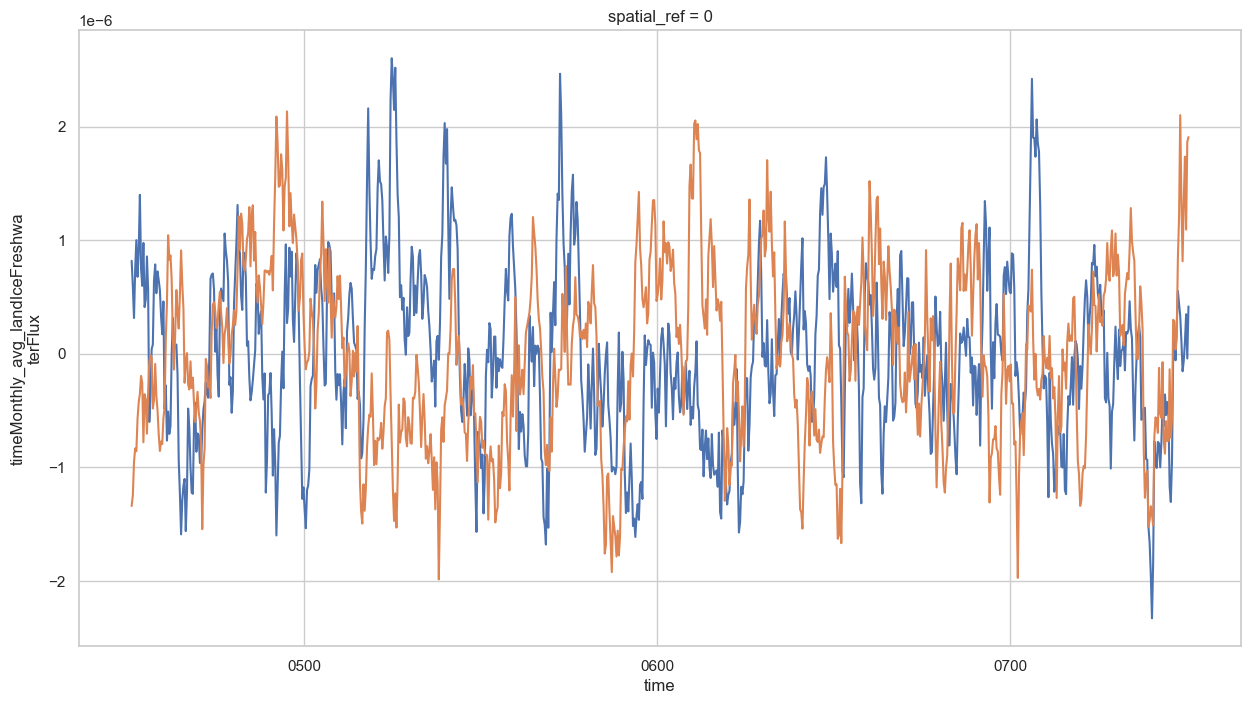

In [72]:
tend = -1

plt.figure(figsize=(15,8))
recon_phys_ts[:tend].plot()
data_ts[:tend].plot()

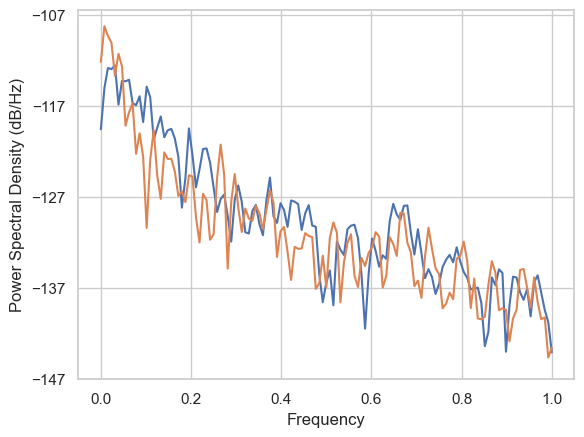

In [73]:
plt.psd(recon_phys_ts);
plt.psd(data_ts);

Saved PSD (vs period) to /Users/smurugan9/research/aislens/AISLENS/data/processed/generator-test/psd_periods.png


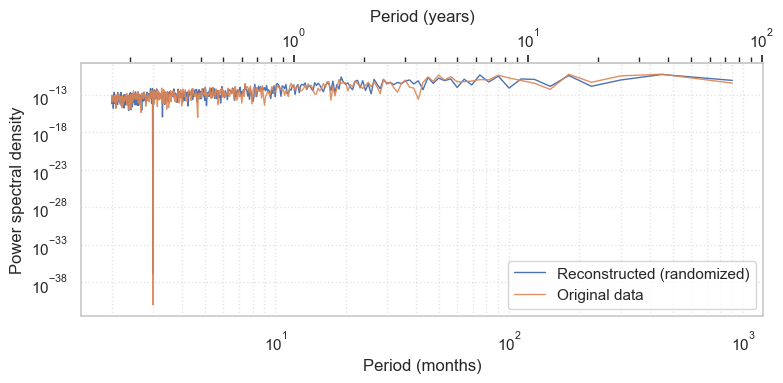

In [74]:
from scipy.signal import periodogram
import numpy as np

# PSD plotted vs period (months & years) with readable x-axis
import matplotlib.pyplot as plt

# sampling: 1 sample per month
fs = 1.0

# signals (1D)
sig_recon = np.asarray(recon_phys_ts)
sig_data = np.asarray(data_ts)

# compute periodograms
f_rec, P_rec = periodogram(sig_recon, fs=fs, scaling='density')
f_dat, P_dat = periodogram(sig_data, fs=fs, scaling='density')

# drop the zero-frequency (DC) bin before converting to periods
mask = f_rec > 0
period_months = 1.0 / f_rec[mask]
P_rec = P_rec[mask]
P_dat = P_dat[mask]

# sort by increasing period for plotting left->right
order = np.argsort(period_months)
period_months = period_months[order]
P_rec = P_rec[order]
P_dat = P_dat[order]

# create plot: period in months on primary x-axis, years on secondary
fig, ax = plt.subplots(figsize=(8,4))
ax.loglog(period_months, P_rec, label='Reconstructed (randomized)', lw=1)
ax.loglog(period_months, P_dat, label='Original data', lw=1, alpha=0.9)
ax.set_xlabel('Period (months)')
ax.set_ylabel('Power spectral density')
ax.grid(which='both', linestyle=':', alpha=0.5)
ax.legend(frameon=True)

# add secondary x-axis in years
secax = ax.secondary_xaxis('top', functions=(lambda x: x/12.0, lambda x: x*12.0))
secax.set_xlabel('Period (years)')

# highlight spectral passband (if provided)
min_m = MIN_PERIOD_YEARS * 12.0 if MIN_PERIOD_YEARS is not None else None
max_m = MAX_PERIOD_YEARS * 12.0 if MAX_PERIOD_YEARS is not None else None
if min_m is not None or max_m is not None:
    xmin = min_m if min_m is not None else period_months.min()
    xmax = max_m if max_m is not None else period_months.max()
    ax.axvspan(xmin, xmax, color='gray', alpha=0.2, label='selected passband')
    ax.legend()

plt.tight_layout()
out_file = OUTPUT_DIR / 'psd_periods.png'
fig.savefig(out_file, dpi=150)
print('Saved PSD (vs period) to', out_file)
plt.show()

In [17]:
# Combine with seasonality (optional) and save preview
if INCLUDE_SEASONALITY:
    ssn_path = getattr(config, 'FILE_SEASONALITY_EXTRAPL', None)
    if ssn_path is None:
        print('Seasonality path not found in config (FILE_SEASONALITY_EXTRAPL) - skipping seasonality add')
        forcing_preview = recon_da
    else:
        ssn_ds = xr.open_dataset(ssn_path)
        if 'Time' in ssn_ds.dims:
            ssn_ds = ssn_ds.rename({'Time': 'time'})
        ssn_var = getattr(config, 'SORRM_FLUX_VAR', list(ssn_ds.data_vars)[0])
        ssn = ssn_ds[ssn_var]
        # coarsen seasonality if we coarsened variability
        if COARSEN_FACTOR and COARSEN_FACTOR > 1:
            ssn = coarsen_dataset(ssn, COARSEN_FACTOR)
        forcing_preview = ssn + recon_da
else:
    forcing_preview = recon_da

out_path = OUTPUT_DIR / 'forcing_preview.nc'
print('Saving preview to', out_path)
forcing_preview.to_netcdf(out_path)


KeyboardInterrupt: 

In [ ]:
# validation checks
assert forcing_preview.shape == data.shape, 'Shape mismatch between preview and original data'
assert not np.any(np.isnan(forcing_preview.values)), 'Preview contains NaNs'
print('Validation checks passed: shape matches and no NaNs in preview')

# Quick PSD comparison for first PC
from scipy.signal import periodogram
orig_pc = pcs_arr[:, 0]
fs, Pxx_orig = periodogram(orig_pc, fs=1.0/1.0)  # sampling=1 month -> fs in cycles/month
# average PSD across randomized PCs
psd_rand = []
for i in range(new_pcs.shape[0]):
    f, Pxx = periodogram(new_pcs[i,:,0], fs=1.0/1.0)
    psd_rand.append(Pxx)
psd_rand = np.mean(psd_rand, axis=0)

fig, ax = plt.subplots(figsize=(6,3))
ax.loglog(1.0/fs, Pxx_orig + 1e-20, label='orig PC')
ax.loglog(1.0/fs, psd_rand + 1e-20, label='avg randomized')
ax.set_xlabel('Period (months)')
ax.set_ylabel('Power')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'psd_comparison.png')
plt.show()


NameError: name 'forcing_preview' is not defined